Nannapat Chatkul
# **Credit Scoring Prediction Model**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import kagglehub

In [2]:
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)
import os
keep_cols = [
    'loan_amnt', 'term', 'int_rate', 'grade',
    'emp_length', 'home_ownership', 'annual_inc',  'loan_status', 'purpose', 'dti', 'revol_util'
]
csv_path = os.path.join(path, "accepted_2007_to_2018Q4.csv.gz")


df = pd.read_csv(csv_path,
                  usecols=keep_cols,
                  compression='gzip',
                  nrows=50000)


df.head()

Using Colab cache for faster access to the 'lending-club' dataset.
Path to dataset files: /kaggle/input/lending-club


,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,revol_util
0,3600.0,36 months,13.99,C,10+ years,MORTGAGE,55000.0,Fully Paid,debt_consolidation,5.91,29.7
1,24700.0,36 months,11.99,C,10+ years,MORTGAGE,65000.0,Fully Paid,small_business,16.06,19.2
2,20000.0,60 months,10.78,B,10+ years,MORTGAGE,63000.0,Fully Paid,home_improvement,10.78,56.2
3,35000.0,60 months,14.85,C,10+ years,MORTGAGE,110000.0,Current,debt_consolidation,17.06,11.6
4,10400.0,60 months,22.45,F,3 years,MORTGAGE,104433.0,Fully Paid,major_purchase,25.37,64.5


In [3]:
df = df.drop(columns=['term'])


In [4]:
df['emp_length'] = df['emp_length'].astype(str)
df['emp_length'] = df['emp_length'].replace({
    '< 1 year': '0',
    '10+ years': '10',
})
df['emp_length'] = df['emp_length'].str.extract('(\d+)').astype(float)
df.dropna(subset=['emp_length', 'revol_util'], inplace=True)
print(df['emp_length'].unique())

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-942873298.py:6: SyntaxWarning: invalid escape sequence '\d'
  df['emp_length'] = df['emp_length'].str.extract('(\d+)').astype(float)


[10.  3.  4.  6.  1.  7.  8.  5.  2.  9.  0.]


In [5]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41225 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loan_amnt       41225 non-null  float64
 1   int_rate        41225 non-null  float64
 2   grade           41225 non-null  object 
 3   emp_length      41225 non-null  float64
 4   home_ownership  41225 non-null  object 
 5   annual_inc      41225 non-null  float64
 6   loan_status     41225 non-null  int64  
 7   purpose         41225 non-null  object 
 8   dti             41225 non-null  float64
 9   revol_util      41225 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.5+ MB


In [7]:
df.head()

,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,revol_util
0,3600.0,13.99,C,10.0,MORTGAGE,55000.0,0,debt_consolidation,5.91,29.7
1,24700.0,11.99,C,10.0,MORTGAGE,65000.0,0,small_business,16.06,19.2
2,20000.0,10.78,B,10.0,MORTGAGE,63000.0,0,home_improvement,10.78,56.2
4,10400.0,22.45,F,3.0,MORTGAGE,104433.0,0,major_purchase,25.37,64.5
5,11950.0,13.44,C,4.0,RENT,34000.0,0,debt_consolidation,10.20,68.4


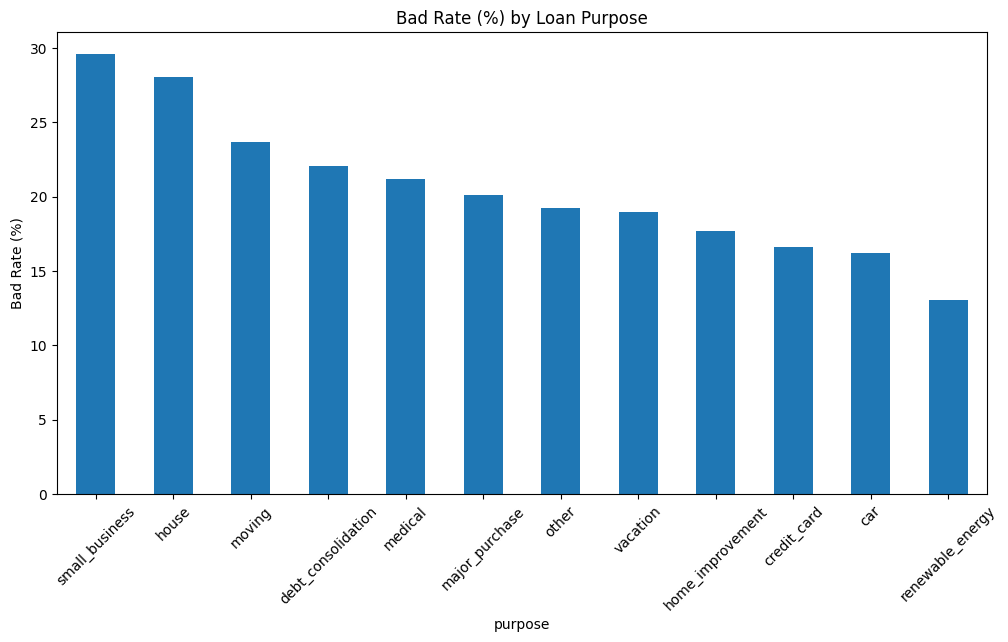

In [8]:
purpose_risk = df.groupby('purpose')['loan_status'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
purpose_risk.plot(kind='bar')
plt.title('Bad Rate (%) by Loan Purpose')
plt.ylabel('Bad Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [9]:
df = df[df['home_ownership'] != 'ANY']
print(df['home_ownership'].value_counts())

home_ownership
MORTGAGE    20114
RENT        16642
OWN          4468
Name: count, dtype: int64


In [10]:
categories = {
    'Debt': ['debt_consolidation'],
    'Card': ['credit_card'],
    'Asset': ['home_improvement', 'house', 'car', 'renewable_energy'],
    'Life': ['other', 'major_purchase', 'medical', 'vacation', 'moving', 'small_business']
}
purpose_map = {v: k for k, vv in categories.items() for v in vv}
df['purpose_cat'] = df['purpose'].map(purpose_map)

new_risk = df.groupby('purpose_cat')['loan_status'].mean().sort_values(ascending=False) * 100
print(new_risk)

purpose_cat
Debt     22.052693
Life     20.789755
Asset    18.007282
Card     16.593503
Name: loan_status, dtype: float64


In [11]:
df.head()

,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,revol_util,purpose_cat
0,3600.0,13.99,C,10.0,MORTGAGE,55000.0,0,debt_consolidation,5.91,29.7,Debt
1,24700.0,11.99,C,10.0,MORTGAGE,65000.0,0,small_business,16.06,19.2,Life
2,20000.0,10.78,B,10.0,MORTGAGE,63000.0,0,home_improvement,10.78,56.2,Asset
4,10400.0,22.45,F,3.0,MORTGAGE,104433.0,0,major_purchase,25.37,64.5,Life
5,11950.0,13.44,C,4.0,RENT,34000.0,0,debt_consolidation,10.20,68.4,Debt


loan_status
Good    32874
Bad      8350
Name: count, dtype: int64
****************************************
loan_status
Good    79.744809
Bad     20.255191
Name: count, dtype: float64
****************************************


/tmp/ipython-input-426752192.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target['loan_status'] = df_target['loan_status'].map({0: 'Good', 1: 'Bad'})
/tmp/ipython-input-426752192.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status',data=df_target, palette='tab10')


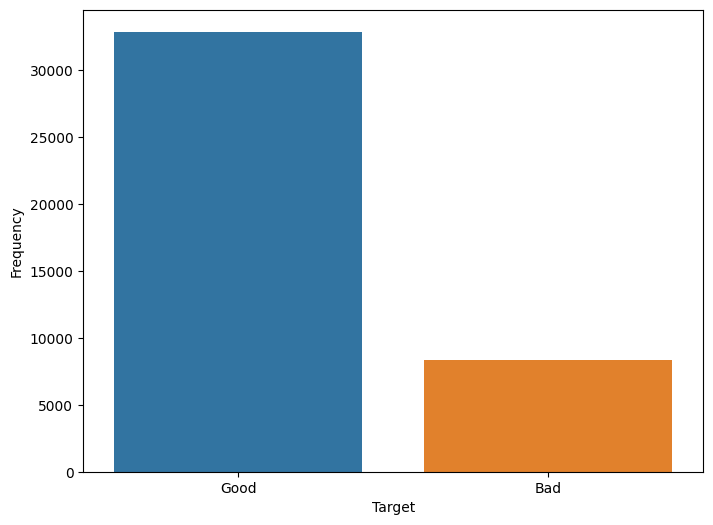

Imbalance Ratio (IR) = 1:3


In [12]:
df_target = df[['loan_status']]
df_target['loan_status'] = df_target['loan_status'].map({0: 'Good', 1: 'Bad'})

print(df_target['loan_status'].value_counts())
print('*'*40)
print(df_target['loan_status'].value_counts()/len(df_target)*100)
print('*'*40)

fig = plt.figure(figsize=(8,6))
sns.countplot(x='loan_status',data=df_target, palette='tab10')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.grid(False)
plt.show();


count_good = len(df_target.loc[df_target['loan_status']=='Good'])
count_bad = len(df_target.loc[df_target['loan_status']=='Bad'])

print("Imbalance Ratio (IR) = 1:{}".format(int(count_good/count_bad)))

In [13]:
df.describe()

,loan_amnt,int_rate,emp_length,annual_inc,loan_status,dti,revol_util
count,41224.000000,41224.000000,41224.000000,4.122400e+04,41224.000000,41224.000000,41224.000000
mean,14542.741486,11.991429,5.913424,8.039710e+04,0.202552,18.984072,51.593312
std,8651.427164,4.192033,3.752818,1.049784e+05,0.401906,8.670566,24.120189
min,1000.000000,5.320000,0.000000,3.800000e+03,0.000000,0.000000,0.000000
25%,8000.000000,9.170000,2.000000,4.900000e+04,0.000000,12.400000,33.600000
50%,12225.000000,11.490000,6.000000,6.788917e+04,0.000000,18.450000,51.200000
75%,20000.000000,14.480000,10.000000,9.500000e+04,0.000000,25.170000,69.900000
max,35000.000000,28.990000,10.000000,9.000000e+06,1.000000,100.090000,145.800000


In [14]:
df.head()

,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,revol_util,purpose_cat
0,3600.0,13.99,C,10.0,MORTGAGE,55000.0,0,debt_consolidation,5.91,29.7,Debt
1,24700.0,11.99,C,10.0,MORTGAGE,65000.0,0,small_business,16.06,19.2,Life
2,20000.0,10.78,B,10.0,MORTGAGE,63000.0,0,home_improvement,10.78,56.2,Asset
4,10400.0,22.45,F,3.0,MORTGAGE,104433.0,0,major_purchase,25.37,64.5,Life
5,11950.0,13.44,C,4.0,RENT,34000.0,0,debt_consolidation,10.20,68.4,Debt


# Univariate Analysis

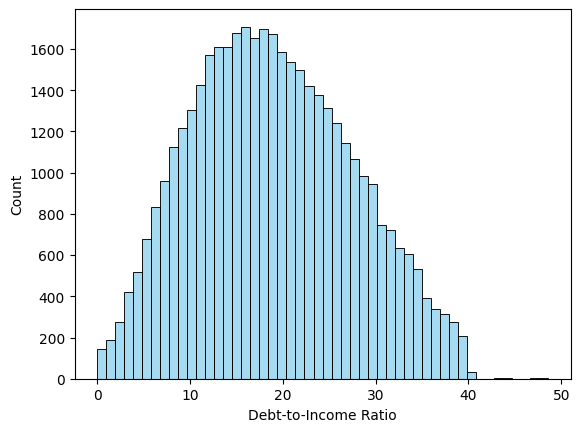

In [15]:
sns.histplot(df[df['dti'] <= 50]['dti'], bins=50, kde=False, color='skyblue')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Count')
plt.grid(False)
plt.show()

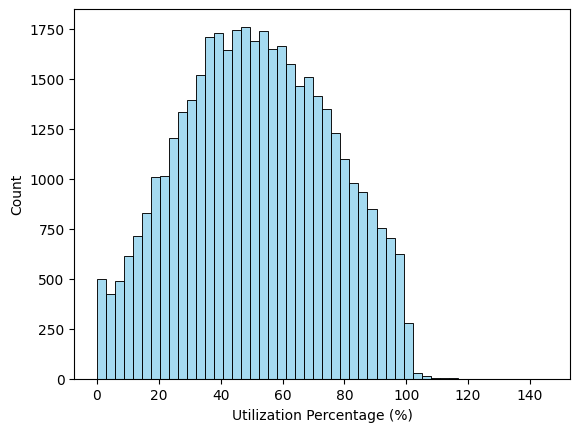

In [16]:
sns.histplot(df['revol_util'], bins=50, kde=False, color='skyblue')
plt.xlabel('Utilization Percentage (%)')
plt.ylabel('Count')
plt.grid(False)
plt.show()

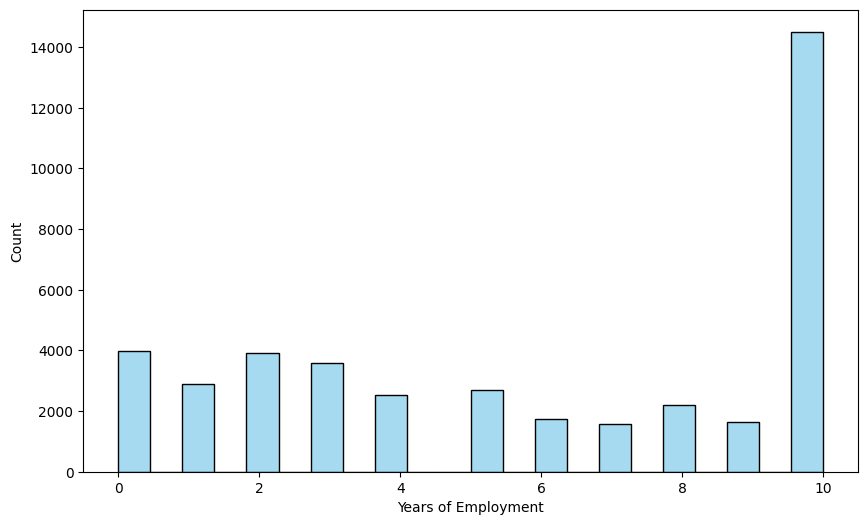

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(df['emp_length'], color='skyblue')
plt.xlabel('Years of Employment')
plt.ylabel('Count')
plt.grid(False)
plt.show()

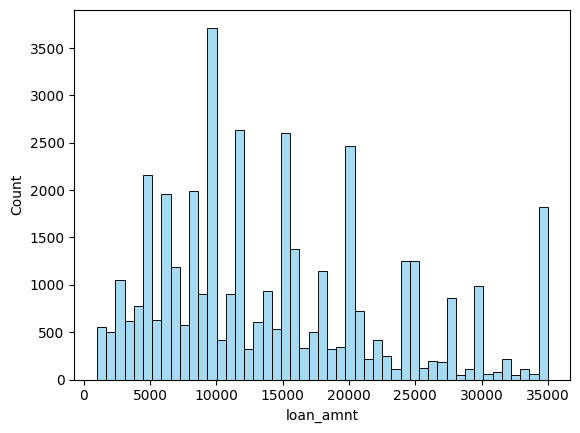

In [18]:
sns.histplot(df['loan_amnt'], kde=False, color='skyblue')
plt.grid(False)
plt.ylabel('Count')
plt.show();

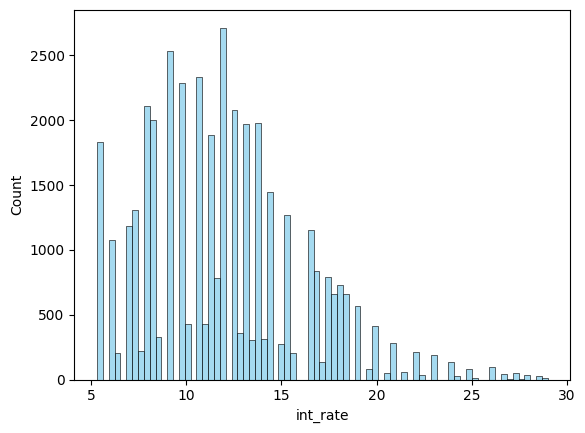

In [19]:
sns.histplot(df['int_rate'], kde=False, color='skyblue')
plt.grid(False)
plt.ylabel('Count')
plt.show();

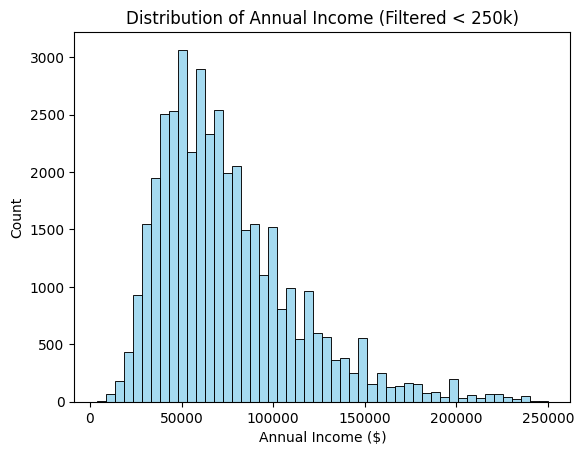

In [20]:
sns.histplot(df[df['annual_inc'] < 250000]['annual_inc'], bins=50, color='skyblue')
plt.title('Distribution of Annual Income (Filtered < 250k)')
plt.xlabel('Annual Income ($)')
plt.ylabel('Count')
plt.grid(False)
plt.show()

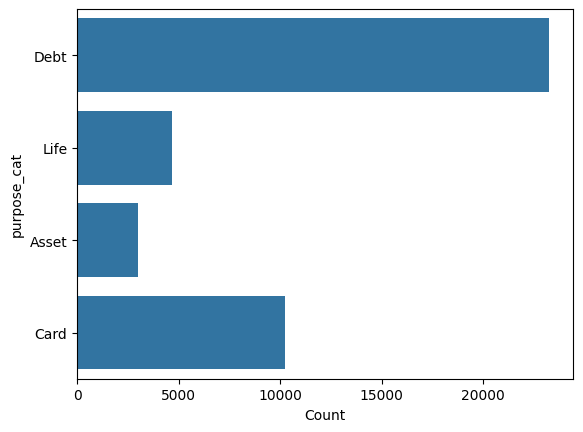

In [21]:
sns.countplot(y="purpose_cat", data=df)
plt.grid(False)
plt.xlabel('Count')
plt.show()

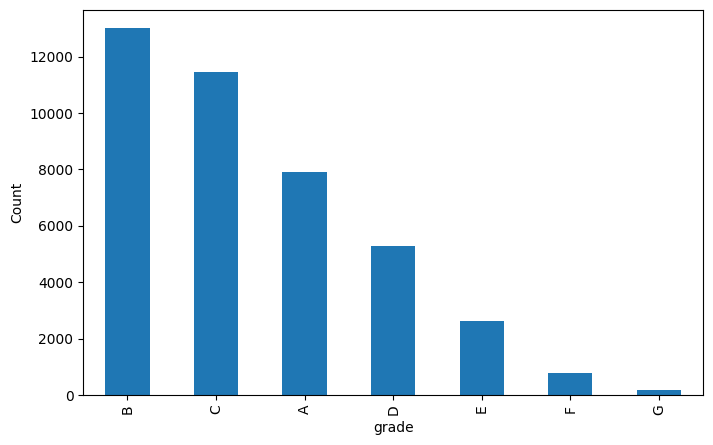

In [22]:
plt.subplots(figsize=(8,5))
df['grade'].value_counts().plot(kind="bar")
plt.grid(False)
plt.ylabel('Count')
plt.show()

# **Bivariate Analysis**

In [23]:
df.groupby('purpose_cat').agg({'loan_amnt': 'mean',
                               'int_rate': 'mean'}).sort_values(by='loan_amnt', ascending=False)

,loan_amnt,int_rate
purpose_cat,,
Debt,15358.530322,12.425958
Card,15184.023510,10.470542
Asset,13231.868587,11.772056
Life,9933.436499,13.302668


In [24]:
df.groupby(by='loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,32874.0,14184.441352,8625.653822,1000.0,7500.0,12000.0,20000.0,35000.0
1,8350.0,15953.371257,8608.937879,1000.0,10000.0,15000.0,21000.0,35000.0


# **EDA**

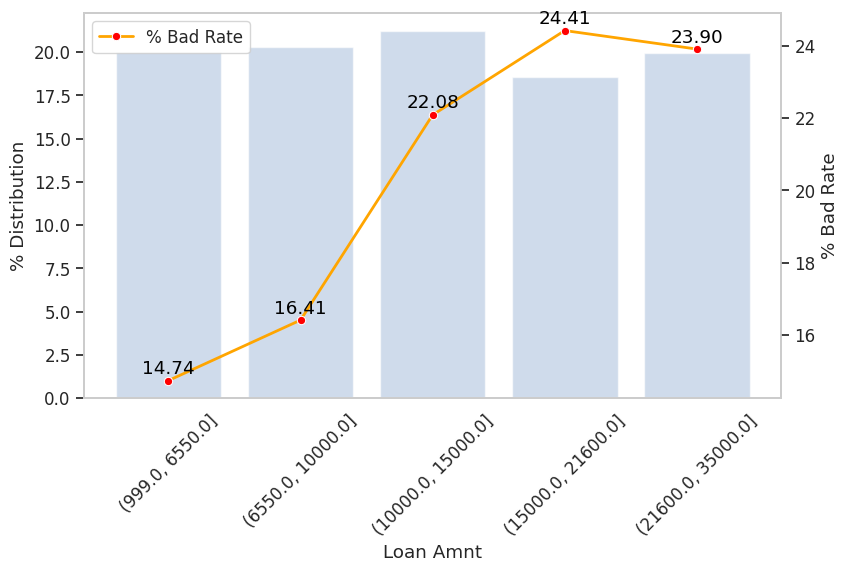

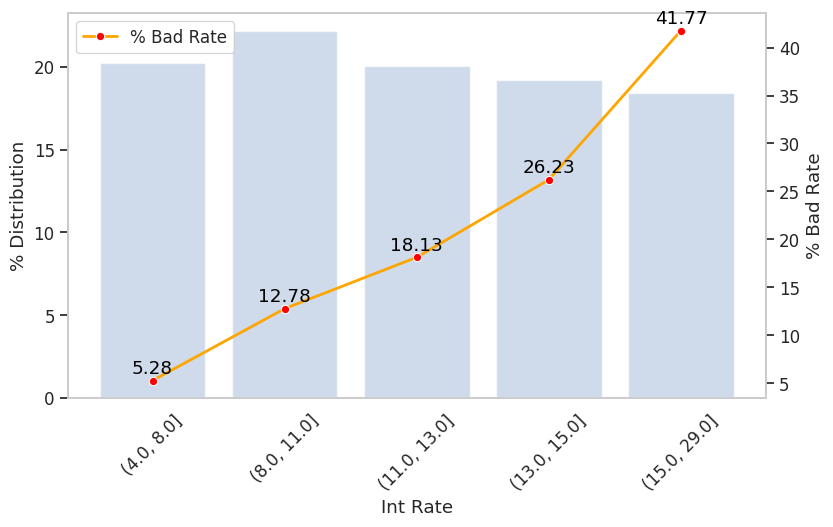

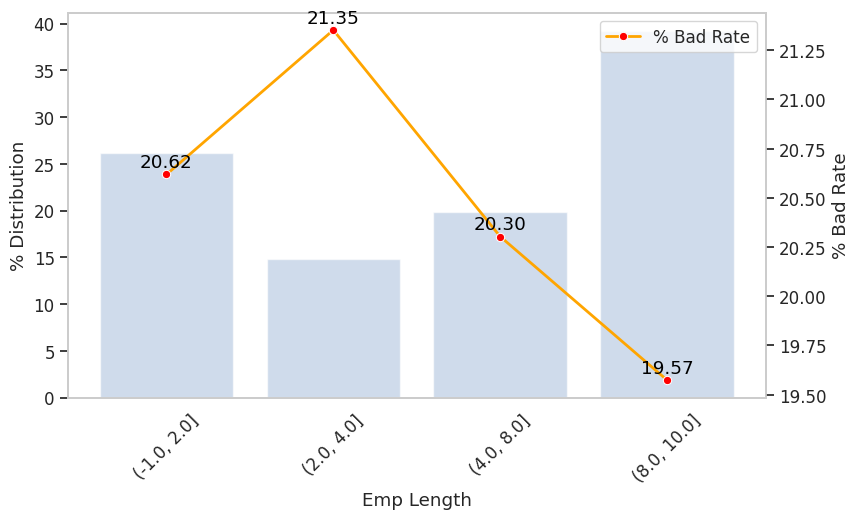

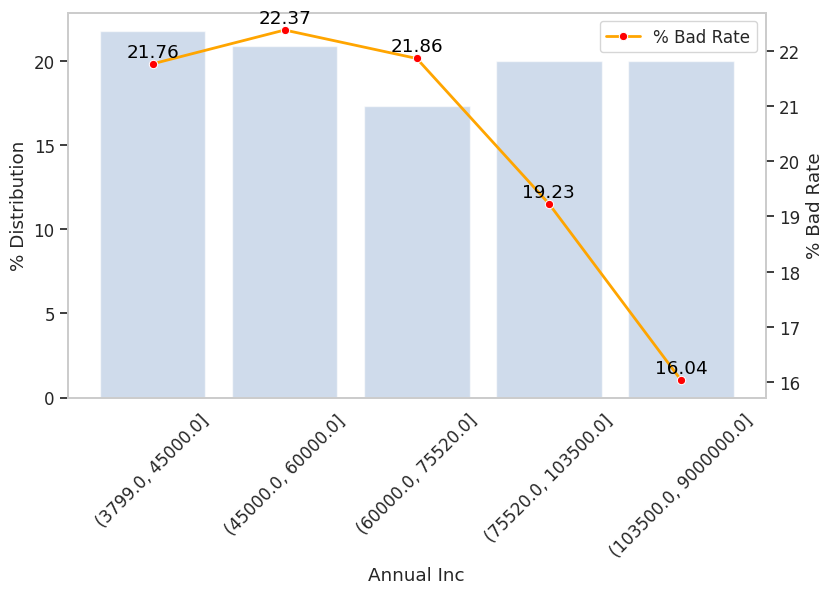

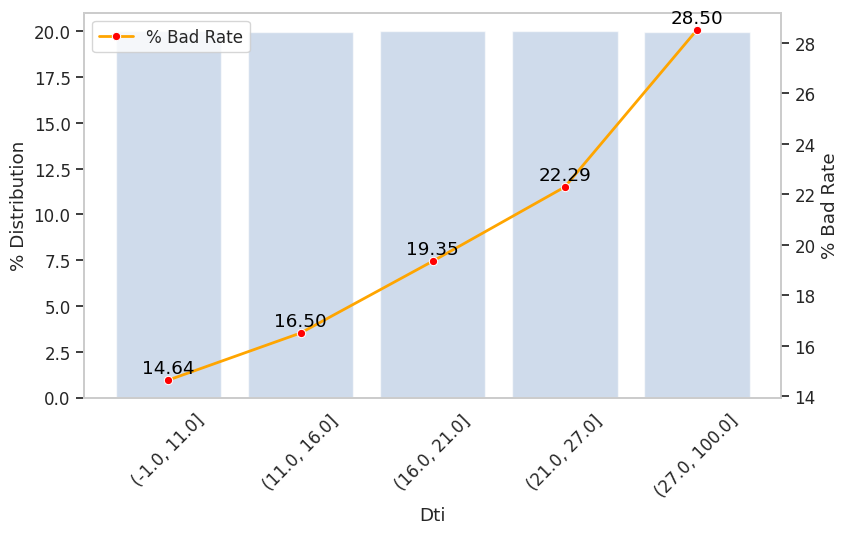

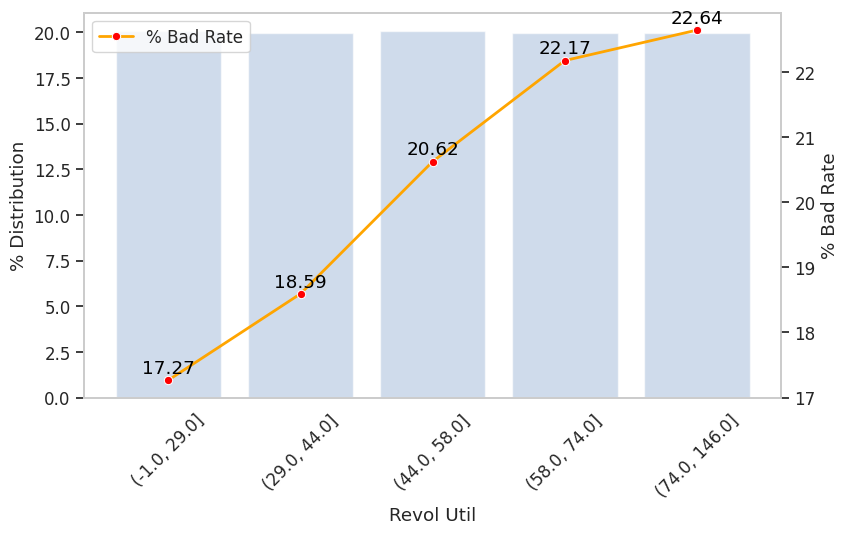

In [25]:
df_plot = df.copy()

for i in df_plot._get_numeric_data().columns:
  if i == 'loan_status':
    pass
  else:

    df_group = df_plot[['loan_status', i]].copy()
    df_group['bin_'+i] = pd.qcut(df_group[i].astype(float), q=5, duplicates='drop', precision=0)
    df_group = df_group.groupby('bin_'+i, observed=False).agg({'loan_status': ['count', 'sum']})
    df_group.columns = df_group.columns.map('_'.join)
    df_group['dist'] = df_group['loan_status_count']/df_group['loan_status_count'].sum()
    df_group['bad_rate'] = df_group['loan_status_sum']/df_group['loan_status_count']
    df_group = df_group.reset_index()

    x1 = df_group['bin_'+i].astype(str)
    x2 = df_group.index
    y1 = df_group['dist']*100
    y2 = df_group['bad_rate']*100

    sns.set(font_scale=1.1)
    sns.set_style("whitegrid")
    fig, ax1  = plt.subplots(figsize=(9,5))
    plt.tick_params(axis='x', rotation = 45)

    ### y axis (left) is bar plot ###

    ax1.bar(x1,y1, data = df_group, color='lightsteelblue', alpha=.6)

    ### y axis (right) is line chart ###
    ax2 = ax1.twinx()
    ax2 = sns.lineplot(x=x2, y=y2, marker='o',\
                    markerfacecolor='red', markersize=6, color='orange',
                    linewidth=2, label='% Bad Rate')
    ax1.set_xlabel(i.replace("_"," ").title())
    ax1.set_ylabel('% Distribution')
    ax2.set_ylabel('% Bad Rate')
    ax1.grid(False)
    ax2.grid(False)

    for x,y in zip(x2,y2):
            label = "{:.2f}".format(y)
            plt.annotate(label, (x,y), textcoords="offset points", xytext=(0,5), ha='center', color='black')


    plt.show();

In [26]:
def mean_target_per_category(df, var):

    temp_df = pd.Series(df[var].value_counts() / len(df)).reset_index()
    temp_df.columns = [var, '%Dist']

    temp_df = temp_df.merge(df.groupby([var])['loan_status'].mean().reset_index(),
                            on=var,
                            how='left').sort_values(by='loan_status').reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    plt.xticks(temp_df.index, temp_df[var], rotation=45)
    ax2 = ax.twinx()
    ax.bar(temp_df.index, temp_df["%Dist"]*100, color='lightsteelblue',
           alpha=.6)

    ax2.plot(temp_df.index, temp_df["loan_status"]*100, color='orange', label='Seconds',
            marker='o', markerfacecolor='red', linewidth=2)
    ax.set_ylabel('% Distribution')
    ax.set_xlabel(var)
    ax2.set_ylabel('% Bad Rate')
    ax.grid(False)
    ax2.grid(False)
    for x,y in zip(temp_df.index, temp_df["loan_status"]*100):
          label = "{:.2f}".format(y)
          plt.annotate(label, (x,y), textcoords="offset points", xytext=(0,5), ha='center', color='black')
    plt.show()

    return temp_df

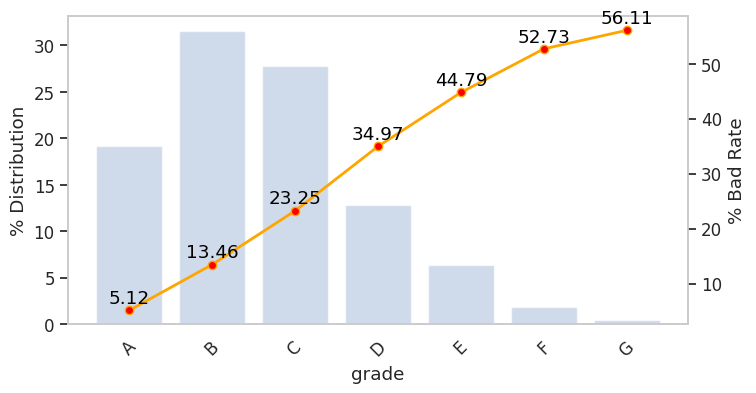

**********************************************************************


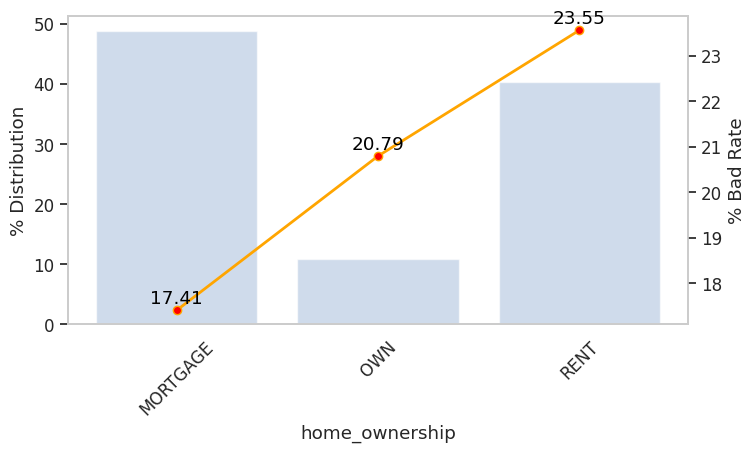

**********************************************************************


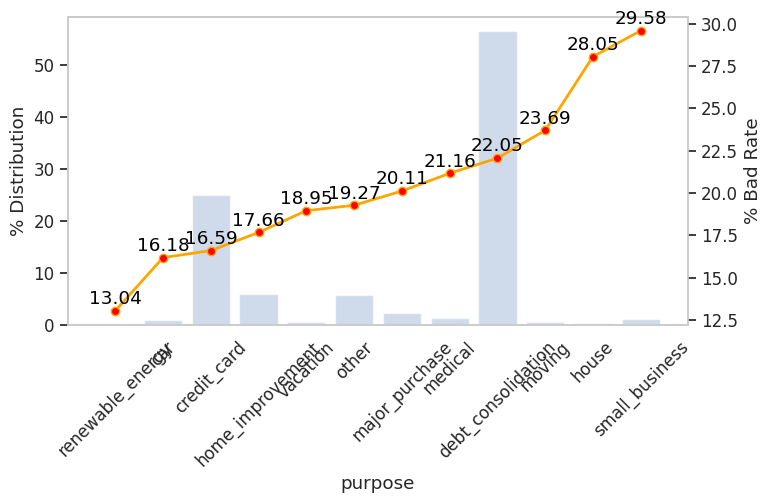

**********************************************************************


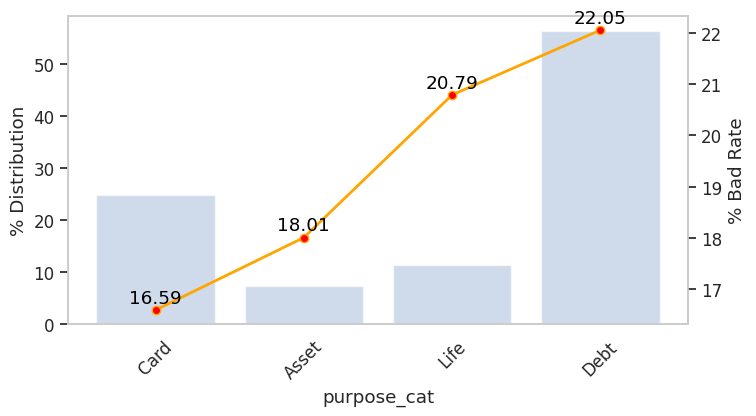

**********************************************************************


In [27]:
for col in df.loc[:, df.dtypes == object].columns:
  df_cat = mean_target_per_category(df, col)
  print('*'*70)

In [28]:
df_cat

,purpose_cat,%Dist,loan_status
0,Card,0.248666,0.165935
1,Asset,0.073283,0.180073
2,Life,0.113647,0.207898
3,Debt,0.564404,0.220527


# **Feature Engineering**

In [29]:
df = df.drop(columns=['purpose'])

In [30]:
df.groupby('purpose_cat').agg({'dti': ['min', 'mean', 'median', 'max']})

dti                          
              min       mean median     max
purpose_cat                                
Asset        0.00  17.029510  16.59   43.98
Card         0.21  18.972272  18.38   57.14
Debt         0.00  19.479981  18.91  100.09
Life         0.00  17.807417  17.35   45.32

In [31]:
df_dti = df[['loan_status', 'dti']].copy()
df_dti['loan_status'] = df_dti['loan_status'].astype(int)
df_dti['bin_dti'] = pd.qcut(df_dti['dti'].astype(float), q=5, duplicates='drop', precision=0)
df_dti = df_dti.groupby('bin_dti', observed=False).agg({'loan_status': ['count', 'sum']})
df_dti.columns = df_dti.columns.map('_'.join)
df_dti['dist'] = df_dti['loan_status_count']/df_dti['loan_status_count'].sum()
df_dti['bad_rate'] = df_dti['loan_status_sum']/df_dti['loan_status_count']
df_dti = df_dti.reset_index()
df_dti

,bin_dti,loan_status_count,loan_status_sum,dist,bad_rate
0,"(-1.0, 11.0]",8256,1209,0.200272,0.146439
1,"(11.0, 16.0]",8234,1359,0.199738,0.165047
2,"(16.0, 21.0]",8249,1596,0.200102,0.193478
3,"(21.0, 27.0]",8247,1838,0.200053,0.222869
4,"(27.0, 100.0]",8238,2348,0.199835,0.285021


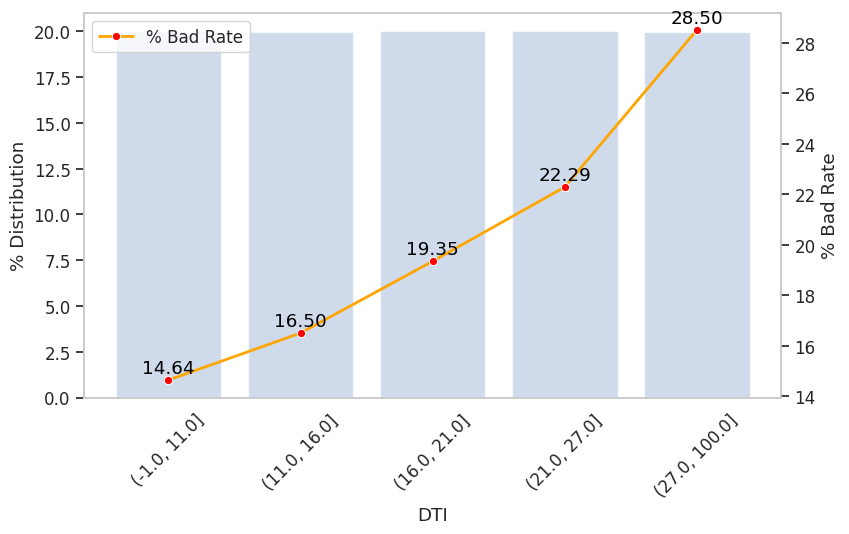

In [32]:
x1 = df_dti['bin_dti'].astype(str)
x2 = df_dti.index
y1 = df_dti['dist']*100
y2 = df_dti['bad_rate']*100

sns.set(font_scale=1.1)
sns.set_style("whitegrid")
fig, ax1  = plt.subplots(figsize=(9,5))
plt.tick_params(axis='x', rotation = 45)

ax1.bar(x1,y1, data = df_dti, color='lightsteelblue', alpha=.6)
ax1.xaxis.grid()
ax2 = ax1.twinx()
ax2 = sns.lineplot(x=x2, y=y2, marker='o',\
                markerfacecolor='red', markersize=6, color='orange',
                linewidth=2, label='% Bad Rate')
ax1.set_xlabel('DTI')
ax1.set_ylabel('% Distribution')
ax2.set_ylabel('% Bad Rate')
ax1.grid(False)
ax2.grid(False)

for x,y in zip(x2,y2):
        label = "{:.2f}".format(y)
        plt.annotate(label, (x,y), textcoords="offset points", xytext=(0,5), ha='center', color='black')


plt.show();

# **WOE & IV**

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41224 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loan_amnt       41224 non-null  float64
 1   int_rate        41224 non-null  float64
 2   grade           41224 non-null  object 
 3   emp_length      41224 non-null  float64
 4   home_ownership  41224 non-null  object 
 5   annual_inc      41224 non-null  float64
 6   loan_status     41224 non-null  int64  
 7   dti             41224 non-null  float64
 8   revol_util      41224 non-null  float64
 9   purpose_cat     41224 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 3.5+ MB


In [34]:
df = df.drop(columns=['grade'])

In [35]:
def binning_numeric(df):

  for i in df._get_numeric_data().columns:
    if i == 'loan_status':
      continue
    else:
      df[i] = pd.qcut(df[i].astype(float), q=5, duplicates='drop', precision=0).astype('object')

  return df

In [36]:
df_bin = binning_numeric(df)
df_bin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41224 entries, 0 to 49998
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   loan_amnt       41224 non-null  object
 1   int_rate        41224 non-null  object
 2   emp_length      41224 non-null  object
 3   home_ownership  41224 non-null  object
 4   annual_inc      41224 non-null  object
 5   loan_status     41224 non-null  int64 
 6   dti             41224 non-null  object
 7   revol_util      41224 non-null  object
 8   purpose_cat     41224 non-null  object
dtypes: int64(1), object(8)
memory usage: 3.1+ MB


In [37]:
df_woe = df_bin.copy()
df_woe.head()

,loan_amnt,int_rate,emp_length,home_ownership,annual_inc,loan_status,dti,revol_util,purpose_cat
0,"(999.0, 6550.0]","(13.0, 15.0]","(8.0, 10.0]",MORTGAGE,"(45000.0, 60000.0]",0,"(-1.0, 11.0]","(29.0, 44.0]",Debt
1,"(21600.0, 35000.0]","(11.0, 13.0]","(8.0, 10.0]",MORTGAGE,"(60000.0, 75520.0]",0,"(16.0, 21.0]","(-1.0, 29.0]",Life
2,"(15000.0, 21600.0]","(11.0, 13.0]","(8.0, 10.0]",MORTGAGE,"(60000.0, 75520.0]",0,"(-1.0, 11.0]","(44.0, 58.0]",Asset
4,"(10000.0, 15000.0]","(15.0, 29.0]","(2.0, 4.0]",MORTGAGE,"(103500.0, 9000000.0]",0,"(21.0, 27.0]","(58.0, 74.0]",Life
5,"(10000.0, 15000.0]","(13.0, 15.0]","(2.0, 4.0]",RENT,"(3799.0, 45000.0]",0,"(-1.0, 11.0]","(58.0, 74.0]",Debt


In [38]:
def woe_iv(df_woe):

  iv_dict = {}
  final_iv = {}

  for i in df_woe.select_dtypes(object).columns:
    d = pd.DataFrame(df_woe.groupby([i]).size(), columns=['total'])

    d['count_bad'] = df_woe.groupby([i])['loan_status'].sum()
    d['count_good'] = d['total']-d['count_bad']

    eps = 0.5
    d['dist_bad']  = (d['count_bad']  + eps) / (d['count_bad'].sum()  + eps*len(d))
    d['dist_good'] = (d['count_good'] + eps) / (d['count_good'].sum() + eps*len(d))

    d['woe'] = np.log(d.dist_bad/d.dist_good)
    d["iv"] = (d.dist_bad-d.dist_good)* d['woe']

    d = d.reset_index()

    ### Append dataframe in dictionary ###
    if i not in final_iv:
      final_iv[i] = []
    final_iv[i].append(d)

    ### Map WOE value ###
    woe_dict = d.groupby([i])['woe'].mean().to_dict()
    df_woe['woe_'+i] = df_woe[i].map(woe_dict)

    ### Calculate final IV of each feature and append in dictionary
    if i not in iv_dict:
      iv_dict[i] = []
    iv_dict[i].append(d['iv'].sum())

  ### Generate IV dataframe
  iv_df = pd.DataFrame.from_dict(iv_dict, orient='index', columns=['IV'])
  iv_df.index.name = 'Feature'

  return final_iv, iv_df, df_woe

In [39]:
final_iv, IV, df_woe = woe_iv(df_woe)

In [40]:
final_iv['dti']

[             dti  total  count_bad  count_good  dist_bad  dist_good       woe  \
 0   (-1.0, 11.0]   8256       1209        7047  0.144807   0.214363 -0.392269   
 1   (11.0, 16.0]   8234       1359        6875  0.162766   0.209131 -0.250650   
 2   (16.0, 21.0]   8249       1596        6653  0.191140   0.202379 -0.057132   
 3   (21.0, 27.0]   8247       1838        6409  0.220114   0.194957  0.121366   
 4  (27.0, 100.0]   8238       2348        5890  0.281173   0.179171  0.450633   
 
          iv  
 0  0.027285  
 1  0.011622  
 2  0.000642  
 3  0.003053  
 4  0.045966  ]

In [41]:
IV.sort_values(by='IV', ascending=False)

,IV
Feature,
int_rate,0.622062
dti,0.088567
loan_amnt,0.062436
home_ownership,0.032118
annual_inc,0.022649
purpose_cat,0.022121
revol_util,0.016447
emp_length,0.001512


In [42]:
df_woe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41224 entries, 0 to 49998
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_amnt           41224 non-null  object 
 1   int_rate            41224 non-null  object 
 2   emp_length          41224 non-null  object 
 3   home_ownership      41224 non-null  object 
 4   annual_inc          41224 non-null  object 
 5   loan_status         41224 non-null  int64  
 6   dti                 41224 non-null  object 
 7   revol_util          41224 non-null  object 
 8   purpose_cat         41224 non-null  object 
 9   woe_loan_amnt       41224 non-null  float64
 10  woe_int_rate        41224 non-null  float64
 11  woe_emp_length      41224 non-null  float64
 12  woe_home_ownership  41224 non-null  float64
 13  woe_annual_inc      41224 non-null  float64
 14  woe_dti             41224 non-null  float64
 15  woe_revol_util      41224 non-null  float64
 16  woe_purpo

In [43]:
df_woe.head()

,loan_amnt,int_rate,emp_length,home_ownership,annual_inc,loan_status,dti,revol_util,purpose_cat,woe_loan_amnt,woe_int_rate,woe_emp_length,woe_home_ownership,woe_annual_inc,woe_dti,woe_revol_util,woe_purpose_cat
0,"(999.0, 6550.0]","(13.0, 15.0]","(8.0, 10.0]",MORTGAGE,"(45000.0, 60000.0]",0,"(-1.0, 11.0]","(29.0, 44.0]",Debt,-0.384936,0.336065,-0.042751,-0.186738,0.126340,-0.392269,-0.106241,0.107713
1,"(21600.0, 35000.0]","(11.0, 13.0]","(8.0, 10.0]",MORTGAGE,"(60000.0, 75520.0]",0,"(16.0, 21.0]","(-1.0, 29.0]",Life,0.212352,-0.137098,-0.042751,-0.186738,0.096489,-0.057132,-0.196331,0.032975
2,"(15000.0, 21600.0]","(11.0, 13.0]","(8.0, 10.0]",MORTGAGE,"(60000.0, 75520.0]",0,"(-1.0, 11.0]","(44.0, 58.0]",Asset,0.240291,-0.137098,-0.042751,-0.186738,0.096489,-0.392269,0.022508,-0.144895
4,"(10000.0, 15000.0]","(15.0, 29.0]","(2.0, 4.0]",MORTGAGE,"(103500.0, 9000000.0]",0,"(21.0, 27.0]","(58.0, 74.0]",Life,0.109433,1.038197,0.066707,-0.186738,-0.284911,0.121366,0.114658,0.032975
5,"(10000.0, 15000.0]","(13.0, 15.0]","(2.0, 4.0]",RENT,"(3799.0, 45000.0]",0,"(-1.0, 11.0]","(58.0, 74.0]",Debt,0.109433,0.336065,0.066707,0.193134,0.090728,-0.392269,0.114658,0.107713


In [44]:
def iv_group(df):

    if df['IV'] > 0.5:
        val = 'Suspicious'
    elif df['IV'] > 0.3 and df['IV'] <= 0.5 :
        val = 'Strong'
    elif df['IV'] > 0.1 and df['IV'] <= 0.3 :
        val = 'Medium'
    elif df['IV'] > 0.02 and df['IV'] <= 0.1 :
        val = 'Weak'
    else:
        val = 'Not useful'

    return val

IV['Predictive_Power'] = IV.apply(iv_group, axis=1)
IV.sort_values('IV',ascending=False)

,IV,Predictive_Power
Feature,,
int_rate,0.622062,Suspicious
dti,0.088567,Weak
loan_amnt,0.062436,Weak
home_ownership,0.032118,Weak
annual_inc,0.022649,Weak
purpose_cat,0.022121,Weak
revol_util,0.016447,Not useful
emp_length,0.001512,Not useful


# **Data Partition**

In [45]:
X = df_woe.loc[:, df_woe.columns.str.startswith('woe_')]
y = df_woe['loan_status']

In [46]:
X.head()

,woe_loan_amnt,woe_int_rate,woe_emp_length,woe_home_ownership,woe_annual_inc,woe_dti,woe_revol_util,woe_purpose_cat
0,-0.384936,0.336065,-0.042751,-0.186738,0.126340,-0.392269,-0.106241,0.107713
1,0.212352,-0.137098,-0.042751,-0.186738,0.096489,-0.057132,-0.196331,0.032975
2,0.240291,-0.137098,-0.042751,-0.186738,0.096489,-0.392269,0.022508,-0.144895
4,0.109433,1.038197,0.066707,-0.186738,-0.284911,0.121366,0.114658,0.032975
5,0.109433,0.336065,0.066707,0.193134,0.090728,-0.392269,0.114658,0.107713


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

loan_status
0    0.797447
1    0.202553
Name: proportion, dtype: float64
loan_status
0    0.797453
1    0.202547
Name: proportion, dtype: float64


# **Logistic Regression**

In [48]:
import statsmodels.api as sm

In [49]:

model = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=True,
                                                        maxiter=100,
                                                        intercept=True)
model.summary()
results_as_html = model.summary().tables[1].as_html()
summary = pd.read_html(results_as_html, header=0, index_col=0)[0]
summary['Feature'] = summary.index
summary = summary.reset_index(drop=True)
summary['Feature'] = summary['Feature'].str.replace('woe_', '')
summary = summary.set_index(['Feature'], drop=True)
summary

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: intercept. After release 0.14, this will raise.
  warnings.warn(
/tmp/ipython-input-2299197449.py:6: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  summary = pd.read_html(results_as_html, header=0, index_col=0)[0]


Optimization terminated successfully.
         Current function value: 0.450319
         Iterations 6


,coef,std err,z,P>|z|,[0.025,0.975]
Feature,,,,,,
const,-1.3686,0.015,-91.631,0.000,-1.398,-1.339
loan_amnt,0.8674,0.062,13.989,0.000,0.746,0.989
int_rate,0.9239,0.021,45.034,0.000,0.884,0.964
emp_length,0.3674,0.380,0.968,0.333,-0.376,1.111
home_ownership,0.8391,0.084,10.002,0.000,0.675,1.003
annual_inc,0.4352,0.108,4.043,0.000,0.224,0.646
dti,0.5232,0.050,10.382,0.000,0.424,0.622
revol_util,-0.1682,0.118,-1.430,0.153,-0.399,0.062
purpose_cat,-0.0804,0.101,-0.794,0.427,-0.279,0.118


In [50]:
def train_model(X_train, y_train):

    model = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=True,
                                                            maxiter=100,
                                                            intercept=True)

    results_as_html = model.summary().tables[1].as_html()
    summary = pd.read_html(results_as_html, header=0, index_col=0)[0]
    summary['Feature'] = summary.index
    summary = summary.reset_index(drop=True)
    summary['Feature'] = summary['Feature'].str.replace('woe_', '')
    summary = summary.set_index(['Feature'], drop=True)

    return model, summary

In [51]:
lr, lr_summary = train_model(X_train, y_train)

Optimization terminated successfully.
         Current function value: 0.450319
         Iterations 6


/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: intercept. After release 0.14, this will raise.
  warnings.warn(
/tmp/ipython-input-3375748298.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  summary = pd.read_html(results_as_html, header=0, index_col=0)[0]


In [52]:
lr_summary

,coef,std err,z,P>|z|,[0.025,0.975]
Feature,,,,,,
const,-1.3686,0.015,-91.631,0.000,-1.398,-1.339
loan_amnt,0.8674,0.062,13.989,0.000,0.746,0.989
int_rate,0.9239,0.021,45.034,0.000,0.884,0.964
emp_length,0.3674,0.380,0.968,0.333,-0.376,1.111
home_ownership,0.8391,0.084,10.002,0.000,0.675,1.003
annual_inc,0.4352,0.108,4.043,0.000,0.224,0.646
dti,0.5232,0.050,10.382,0.000,0.424,0.622
revol_util,-0.1682,0.118,-1.430,0.153,-0.399,0.062
purpose_cat,-0.0804,0.101,-0.794,0.427,-0.279,0.118


# **Predict Results**

In [53]:
y_pred_train = lr.predict(sm.add_constant(X_train))
y_pred_test = lr.predict(sm.add_constant(X_test))

y_pred_test

,0
42700,0.210276
32554,0.204552
40077,0.047081
13675,0.122820
5507,0.150750
...,...
31423,0.059661
19276,0.049726
46366,0.238338
21387,0.174650


# **VIF (Variance Inflation Factor)**

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [55]:
def vif_calculation(X):

  features = X.copy()
  features.columns = features.columns.str.replace('woe_', '')
  features = features.assign(const=1)

  vif = pd.DataFrame()
  vif["Feature"] = features.columns
  vif["VIF Factor"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]

  return vif

In [56]:
vif = vif_calculation(X)
vif

,Feature,VIF Factor
0,loan_amnt,1.134641
1,int_rate,1.156817
2,emp_length,1.032817
3,home_ownership,1.079948
4,annual_inc,1.224797
5,dti,1.106451
6,revol_util,1.079546
7,purpose_cat,1.046266
8,const,1.062893


# **Model Evaluation**

In [57]:
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, classification_report

In [58]:
def roc_gini(y, y_pred_proba):

  assert y.shape == y_pred_proba.shape
  fpr, tpr, _ = metrics.roc_curve(y, y_pred_proba)
  auc = metrics.roc_auc_score(y, y_pred_proba)
  gini = (2 * auc - 1)*100

  fig = plt.figure(figsize=(8,6))
  plt.plot(fpr, tpr, color='C0', label='%s AUC = %0.4f, Gini = %0.2f' % ('Model: ', auc,  gini),
           linewidth=2.5)
  plt.plot([0, 1], [0, 1], color='darkgrey', linestyle='--', linewidth=2)
  plt.xlim([-0.01, 1.01])
  plt.ylim([-0.01, 1.01])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.legend(loc='lower right',fontsize='small')
  plt.grid(False)
  plt.show()

Training set


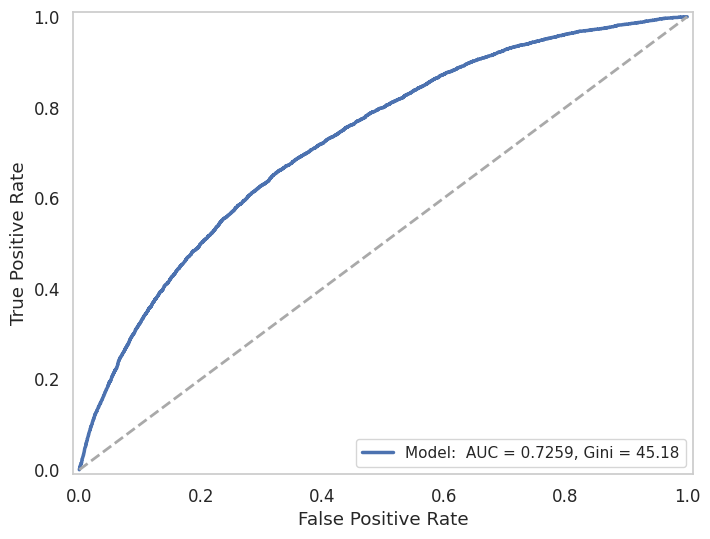

Test set


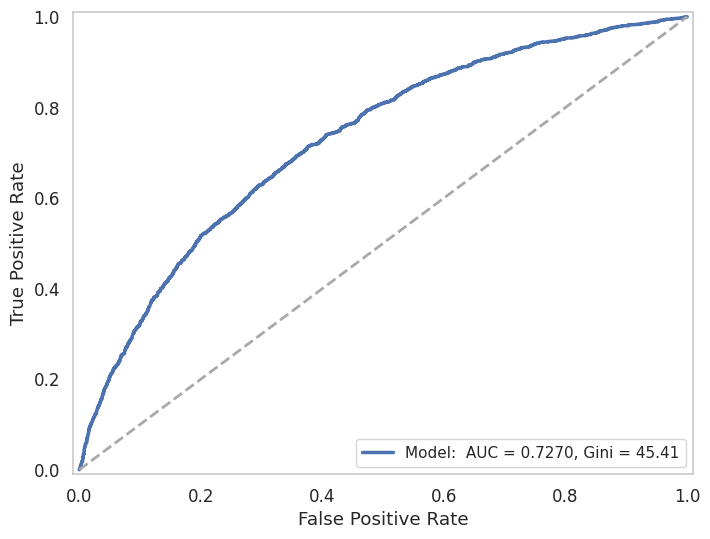

In [59]:
print('Training set')
roc_gini(y_train.values, y_pred_train)

print('Test set')
roc_gini(y_test.values, y_pred_test)

# **Summary Overall of Model**

In [60]:
def summary_model(IV, vif, summary):

    summary_model = IV.merge(vif, left_on= 'Feature', right_on='Feature').merge(lr_summary ,on='Feature')
    summary_model = summary_model.rename(columns={'P>|z|': "p-value", "VIF Factor": "vif", "IV":"iv"})
    summary_model['feature_importance'] = (summary_model['coef'].abs()/summary_model['coef'].abs().sum())*100

    return summary_model

In [61]:
summary = summary_model(IV, vif, lr_summary)
summary

,Feature,iv,Predictive_Power,vif,coef,std err,z,p-value,[0.025,0.975],feature_importance
0,loan_amnt,0.062436,Weak,1.134641,0.8674,0.062,13.989,0.000,0.746,0.989,20.628805
1,int_rate,0.622062,Suspicious,1.156817,0.9239,0.021,45.034,0.000,0.884,0.964,21.972508
2,emp_length,0.001512,Not useful,1.032817,0.3674,0.380,0.968,0.333,-0.376,1.111,8.737633
3,home_ownership,0.032118,Weak,1.079948,0.8391,0.084,10.002,0.000,0.675,1.003,19.955765
4,annual_inc,0.022649,Weak,1.224797,0.4352,0.108,4.043,0.000,0.224,0.646,10.350076
5,dti,0.088567,Weak,1.106451,0.5232,0.050,10.382,0.000,0.424,0.622,12.442922
6,revol_util,0.016447,Not useful,1.079546,-0.1682,0.118,-1.430,0.153,-0.399,0.062,4.000190
7,purpose_cat,0.022121,Weak,1.046266,-0.0804,0.101,-0.794,0.427,-0.279,0.118,1.912100


# **Model Tuning**

Remove some features (p-value > 0.005)

Remove some features (not risk ranking e.g. loan_amnt)

Remove some features (low predictive power from IV e.g. not-useful)

In [62]:
summary['Feature'].loc[summary['p-value']>0.005].to_list()

['emp_length', 'revol_util', 'purpose_cat']

In [79]:
X_2 = X.drop(['woe_purpose_cat', 'woe_emp_length', 'woe_revol_util'], axis=1)
y_2 = df_woe['loan_status']

In [80]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=99, stratify=y)

In [81]:
lr_2, lr_2_summary = train_model(X_train_2, y_train_2)

Optimization terminated successfully.
         Current function value: 0.450373
         Iterations 6


/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: intercept. After release 0.14, this will raise.
  warnings.warn(
/tmp/ipython-input-3375748298.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  summary = pd.read_html(results_as_html, header=0, index_col=0)[0]


In [82]:
y_pred_train_2 = lr_2.predict(sm.add_constant(X_train_2))
y_pred_test_2 = lr_2.predict(sm.add_constant(X_test_2))

Training set


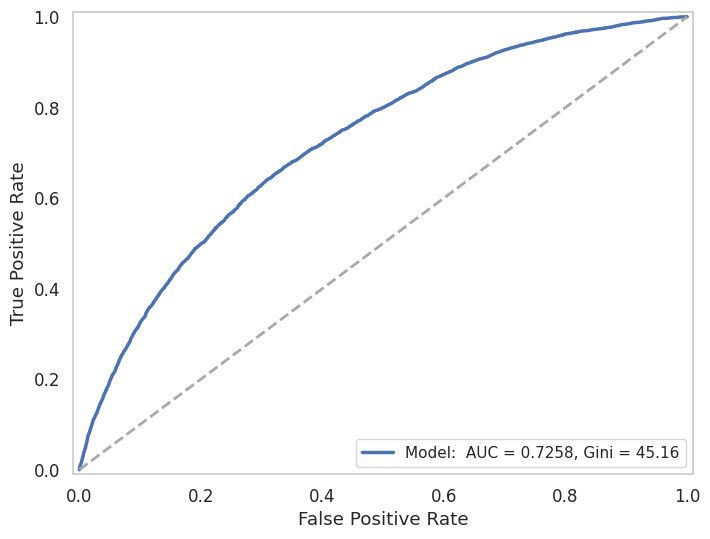

Test set


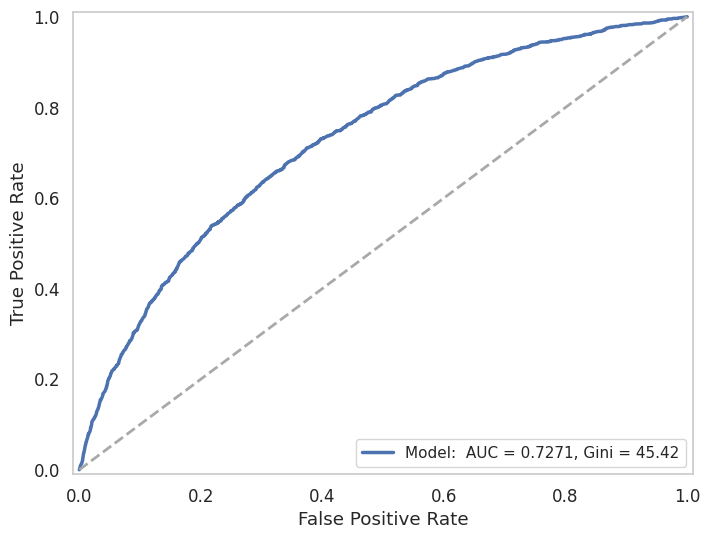

In [83]:
print('Training set')
roc_gini(y_train_2.values, y_pred_train_2)

print('Test set')
roc_gini(y_test_2.values, y_pred_test_2)

In [84]:
vif_2 = vif_calculation(X_2)
vif_2

,Feature,VIF Factor
0,loan_amnt,1.132810
1,int_rate,1.074714
2,home_ownership,1.054542
3,annual_inc,1.211654
4,dti,1.084749
5,const,1.062660


In [85]:
summary_2 = summary_model(IV, vif_2, lr_2_summary)
summary_2.sort_values(by='feature_importance', ascending=False)

,Feature,iv,Predictive_Power,vif,coef,std err,z,p-value,[0.025,0.975],feature_importance
1,int_rate,0.622062,Suspicious,1.074714,0.9239,0.021,45.034,0.0,0.884,0.964,25.743981
0,loan_amnt,0.062436,Weak,1.132810,0.8674,0.062,13.989,0.0,0.746,0.989,24.169639
2,home_ownership,0.032118,Weak,1.054542,0.8391,0.084,10.002,0.0,0.675,1.003,23.381074
4,dti,0.088567,Weak,1.084749,0.5232,0.050,10.382,0.0,0.424,0.622,14.578689
3,annual_inc,0.022649,Weak,1.211654,0.4352,0.108,4.043,0.0,0.224,0.646,12.126616


# **Final Model**

Optimization terminated successfully.
         Current function value: 0.450353
         Iterations 6


/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: intercept. After release 0.14, this will raise.
  warnings.warn(


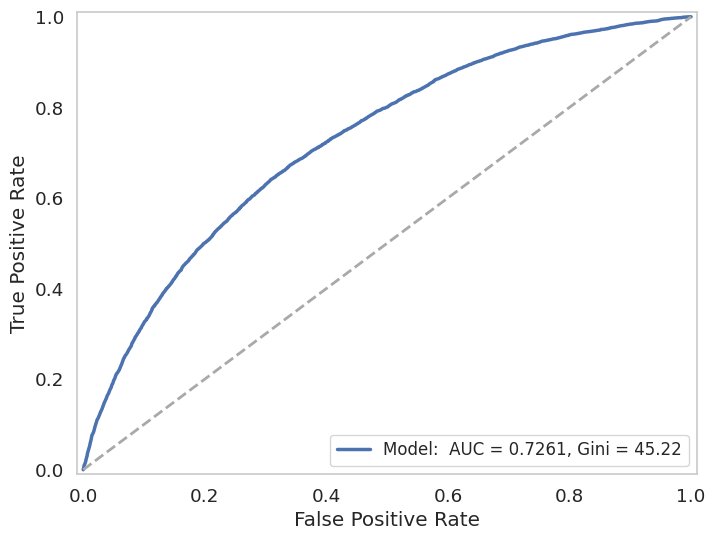

************************************************************
              precision    recall  f1-score   support

        Good       0.81      0.99      0.89     32874
         Bad       0.57      0.07      0.13      8350

    accuracy                           0.80     41224
   macro avg       0.69      0.53      0.51     41224
weighted avg       0.76      0.80      0.73     41224



In [86]:
X_final = X.drop(['woe_purpose_cat', 'woe_emp_length', 'woe_revol_util'], axis=1)
y_final = df_woe['loan_status']

df_grade = df_woe.copy()
threshold = 0.5

final_model = sm.Logit(y_final, sm.add_constant(X_final)).fit(disp=True, maxiter=100, intercept=True)

df_grade['pd'] = final_model.predict(sm.add_constant(X_final))
df_grade['prediction'] = np.where(df_grade['pd'] >= threshold, 1, 0)

sns.set(font_scale=1.2)
sns.set_style("whitegrid")
roc_gini(y_final.values, df_grade['pd'].values)
print('*'*60)
target_names = ['Good', 'Bad']
print(classification_report(y_final.values, df_grade['prediction'].values, target_names=target_names))

# **Score Grading**

/tmp/ipython-input-3505579075.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_grade['pd'], kde=False, bins=30)


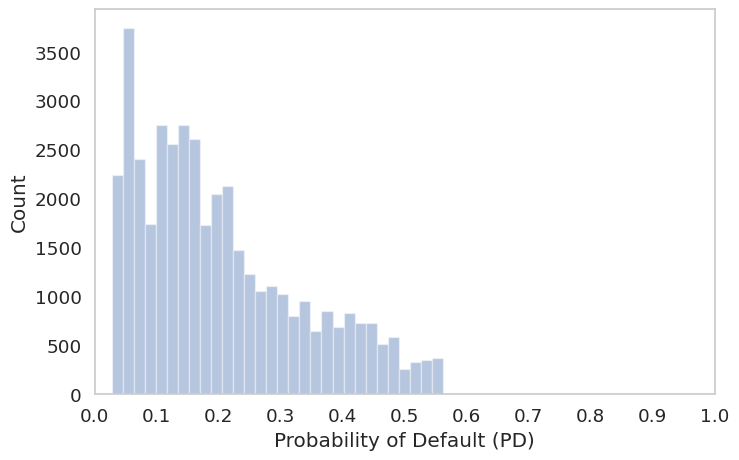

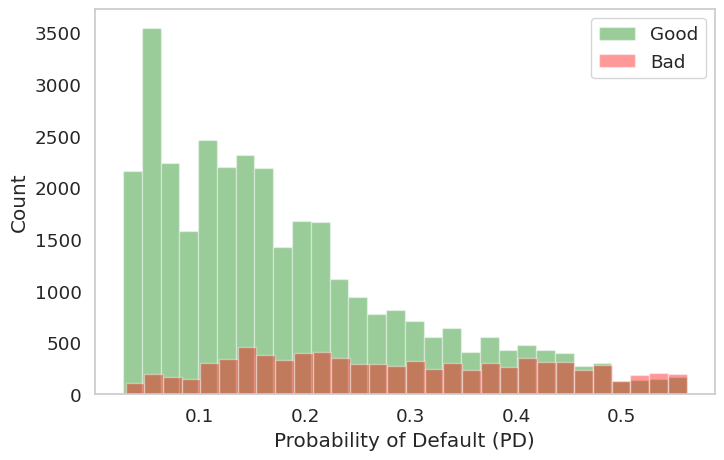

In [89]:
df_grade['score_grade'] = pd.cut(df_grade['pd'],
                                      bins=[0, 0.05, 0.10, 0.15, 0.30, 0.50, 0.70, 1],
                                      labels=['A', 'B', 'C', 'D', 'E', 'F', 'G'])

fig= plt.figure(figsize=(8,5))
sns.distplot(df_grade['pd'], kde=False, bins=30)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Count')
plt.grid(False)
plt.show();

x_good = df_grade['pd'].loc[df_grade['loan_status']==0].values
x_bad = df_grade['pd'].loc[df_grade['loan_status']==1].values

fig, ax = plt.subplots(figsize=(8,5))
ax = plt.hist(x_good, label='Good', bins=30, alpha=.4, color='green')
ax = plt.hist(x_bad, label='Bad', bins=30, alpha=.4, color='red')
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Count')
plt.legend()
plt.grid(False)
plt.show();

In [90]:
report = df_grade[['score_grade', 'loan_status']]
report = report.groupby('score_grade').agg({'loan_status': ['count', 'sum']})
report.columns = report.columns.map('_'.join)
report['dist'] = report['loan_status_count']/report['loan_status_count'].sum()
report['bad_rate'] = report['loan_status_sum']/report['loan_status_count']
report

/tmp/ipython-input-3376497938.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = report.groupby('score_grade').agg({'loan_status': ['count', 'sum']})


,loan_status_count,loan_status_sum,dist,bad_rate
score_grade,,,,
A,3559,145,0.086333,0.040742
B,6799,470,0.164928,0.069128
C,7328,980,0.177761,0.133734
D,14126,2936,0.342664,0.207844
E,8340,3205,0.202309,0.384293
F,1072,614,0.026004,0.572761
G,0,0,0.000000,NaN


In [91]:
def plot_score_grade(report):

  fig, ax = plt.subplots(figsize=(10,6))
  sns.set(font_scale=1.2)
  sns.set_style("whitegrid")

  x1 = report.index
  y1 = np.round(report['dist'].values*100, 2)
  x2 = x1
  y2 = np.round(report['bad_rate'].values*100, 2)

  ax.bar(x1,y1, data = report, color='lightsteelblue', label='% Distribution', alpha=.6)
  ax.yaxis.grid(False)
  ax.xaxis.grid(False)
  ax.set_xlabel('Score Grade')
  ax.set_ylabel('% Distribution')

  xlocs, xlabs = plt.xticks()
  plt.xticks(xlocs, xlabs)
  for i, v in enumerate(y1):
      plt.text(xlocs[i] - 0.2, v + 0.02, str(v))

  ax2 = ax.twinx()
  ax2 = sns.lineplot(data=report, x=x2, y=y2, marker='o', markerfacecolor='red',
                     markersize=8, color='yellowgreen', linewidth=2.5, linestyle='-',
                     label='% Bad Rate')
  ax2.set_ylabel('% Bad Rate')
  ax2.yaxis.grid(False)
  ax2.xaxis.grid(False)
  ax.legend(loc='lower left', bbox_to_anchor=(0.27, 0.88))
  ax2.legend(loc='lower left', bbox_to_anchor=(0.54, 0.88))
  ax.set_ylim([0, 39])
  ax2.set_ylim([-0.5, 92])

  for x,y in zip(x2,y2):
          label = "{:.2f}".format(y)
          plt.annotate(label, (x,y), textcoords="offset points", xytext=(0,5), ha='center', color='black')

  plt.tight_layout(pad=3.0)

  plt.show();

  return

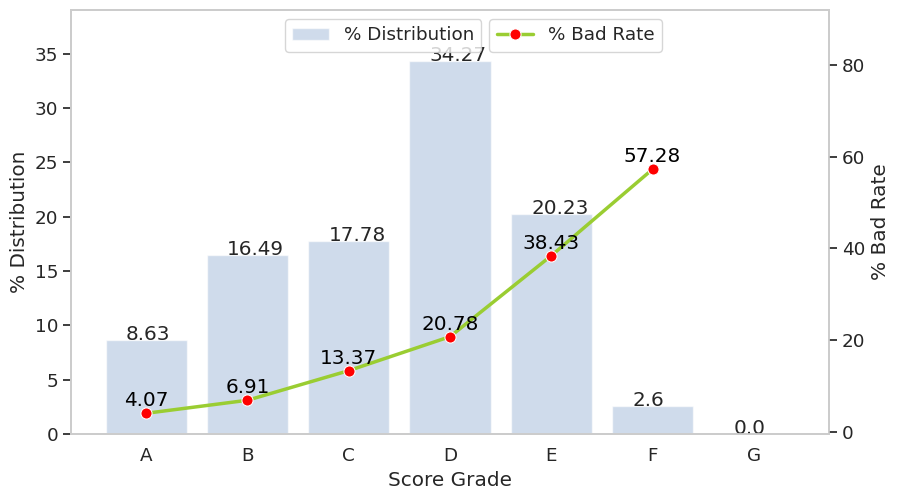

In [92]:
plot_score_grade(report)

# **Score impact and business suggestion**

In [93]:
df_impact = df_grade[['loan_status', 'pd', 'prediction', 'score_grade']]
grade = 'A'

### Choose Cut-off
print('Cut-off is {}'.format(grade))
print('*'*40)
df_impact['status'] = np.where(df_impact['pd']<=0.05, 'Approved', 'Rejected')

### Calculate % approval rate ###
approve = df_impact.loc[(df_impact['status']=='Approved')].shape[0]
reject = df_impact.loc[(df_impact['status']=='Rejected')].shape[0]
approval_rate = np.round((approve/(approve+reject))*100,2)
print('Total = {}'.format(approve+reject))
print('Approved = {}'.format(approve))
print('Rejected = {}'.format(reject))
print('Approval rate = {} %'.format(approval_rate))
print('*'*40)

### Calculate % bad rate ###
bad = df_impact.loc[(df_impact['status']=='Approved')&(df_impact['loan_status']==1)].shape[0]
good = df_impact.loc[(df_impact['status']=='Approved')&(df_impact['loan_status']==0)].shape[0]
bad_rate = np.round((bad/(good+bad))*100,2)
print('Bad = {}'.format(bad))
print('Good = {}'.format(good))
print('Bad rate = {} %'.format(bad_rate))

print('*'*40)

Cut-off is A
****************************************
Total = 41224
Approved = 3559
Rejected = 37665
Approval rate = 8.63 %
****************************************
Bad = 145
Good = 3414
Bad rate = 4.07 %
****************************************


/tmp/ipython-input-2275887626.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_impact['status'] = np.where(df_impact['pd']<=0.05, 'Approved', 'Rejected')


In [94]:
def cut_off(df_grade):

    df_impact = df_grade.copy()
    cut_off_grade = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    cut_off_pd = [0.05, 0.1, 0.15, 0.3, 0.5, 0.7, 1]
    rows = []
    for i in cut_off_pd:
        df_impact['status'] = np.where(df_impact['pd']<=i, 'Approved', 'Rejected')

        ### Calculate % approval rate ###

        approve = df_impact.loc[(df_impact['status']=='Approved')].shape[0]
        reject = df_impact.loc[(df_impact['status']=='Rejected')].shape[0]
        approval_rate = np.round((approve/(approve+reject))*100,2)

        ### Calculate % bad rate ###
        bad = df_impact.loc[(df_impact['status']=='Approved')&(df_impact['loan_status']==1)].shape[0]
        good = df_impact.loc[(df_impact['status']=='Approved')&(df_impact['loan_status']==0)].shape[0]
        bad_rate = np.round((bad/(good+bad))*100,2)

        rows.append([i, approve, reject, approval_rate, good, bad, bad_rate])
        print(rows)

    df_cut_off = pd.DataFrame(rows, columns=["pd", "approved", "rejected",
                                             "%_approval_rate", "good", "bad", "%_bad_rate"])
    df_cut_off['grade'] = cut_off_grade
    df_cut_off = df_cut_off[["grade", "pd", "approved", "rejected",
                             "%_approval_rate", "good", "bad", "%_bad_rate"]]

    return df_cut_off

In [95]:
df_cut_off = cut_off(df_grade)
df_cut_off

[[0.05, 3559, 37665, np.float64(8.63), 3414, 145, np.float64(4.07)]]
[[0.05, 3559, 37665, np.float64(8.63), 3414, 145, np.float64(4.07)], [0.1, 10358, 30866, np.float64(25.13), 9743, 615, np.float64(5.94)]]
[[0.05, 3559, 37665, np.float64(8.63), 3414, 145, np.float64(4.07)], [0.1, 10358, 30866, np.float64(25.13), 9743, 615, np.float64(5.94)], [0.15, 17686, 23538, np.float64(42.9), 16091, 1595, np.float64(9.02)]]
[[0.05, 3559, 37665, np.float64(8.63), 3414, 145, np.float64(4.07)], [0.1, 10358, 30866, np.float64(25.13), 9743, 615, np.float64(5.94)], [0.15, 17686, 23538, np.float64(42.9), 16091, 1595, np.float64(9.02)], [0.3, 31812, 9412, np.float64(77.17), 27281, 4531, np.float64(14.24)]]
[[0.05, 3559, 37665, np.float64(8.63), 3414, 145, np.float64(4.07)], [0.1, 10358, 30866, np.float64(25.13), 9743, 615, np.float64(5.94)], [0.15, 17686, 23538, np.float64(42.9), 16091, 1595, np.float64(9.02)], [0.3, 31812, 9412, np.float64(77.17), 27281, 4531, np.float64(14.24)], [0.5, 40152, 1072, np.fl

,grade,pd,approved,rejected,%_approval_rate,good,bad,%_bad_rate
0,A,0.05,3559,37665,8.63,3414,145,4.07
1,B,0.10,10358,30866,25.13,9743,615,5.94
2,C,0.15,17686,23538,42.90,16091,1595,9.02
3,D,0.30,31812,9412,77.17,27281,4531,14.24
4,E,0.50,40152,1072,97.40,32416,7736,19.27
5,F,0.70,41224,0,100.00,32874,8350,20.26
6,G,1.00,41224,0,100.00,32874,8350,20.26
